# Performance Analysis: Small Files vs Compacted Files

This notebook analyzes the impact of file compaction on object-storage workloads executed on MinIO.

Two dataset layouts are compared:
- **small**: many small files
- **compact**: the same logical data reorganized into fewer larger files

Three dataset scales are evaluated:
- **S**: 5 million rows
- **M**: 25 million rows
- **L**: 100 million rows

The notebook focuses on four benchmark dimensions:
- upload throughput
- download throughput
- object listing time
- query execution time

The goal is to determine whether compaction improves storage and processing performance, and how this effect evolves as dataset size increases.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

In [2]:
csv_path = 'results/results.csv'
df = pd.read_csv(csv_path)
df['size_order'] = df['size'].map({'S': 1, 'M': 2, 'L': 3})
df = df.sort_values(['size_order', 'layout']).reset_index(drop=True)
df

,timestamp_utc,host,dataset_id,size,layout,compression,seed,rows_per_file_small,requested_compact_files,total_rows_expected,query_region,query_start_ts,query_end_ts,local_source_dir,s3_prefix,local_file_count,local_total_bytes,deleted_existing_objects,delete_prefix_elapsed_s,upload_file_count,upload_total_bytes,upload_elapsed_s,upload_throughput_mb_s,listing_object_count,listing_total_bytes,listing_elapsed_s,query_elapsed_s,query_filtered_rows,query_grouped_rows,download_dir,download_file_count,download_total_bytes,download_elapsed_s,download_throughput_mb_s,generation_elapsed_s,generated_small_file_count,compaction_elapsed_s,compact_total_rows,compact_actual_file_count,compact_rows_per_output_file,size_order
0,2026-05-07T14:37:49.240489+00:00,ccbd-2026-11,tollgate_s,S,compact,none,67,10000,20,5000000,tollgate_a1_geneva,2025-01-15T00:00:00+00:00,2025-02-15T00:00:00+00:00,data/curated/tollgate_s/compact,bench/tollgate_s/compact,20,109302123,0,0.000,20,109302123,3.374,30.893,20,109302123,0.014,0.384,343968,5,bench_downloads/tollgate_s/compact,20,109302123,0.923,112.958,21.847,500,3.063,5000000,20,250000,1
1,2026-05-07T14:37:44.489459+00:00,ccbd-2026-11,tollgate_s,S,small,none,67,10000,20,5000000,tollgate_a1_geneva,2025-01-15T00:00:00+00:00,2025-02-15T00:00:00+00:00,data/curated/tollgate_s/small,bench/tollgate_s/small,500,110836997,500,0.231,500,110836997,13.259,7.972,500,110836997,0.148,1.470,343968,5,bench_downloads/tollgate_s/small,500,110836997,8.533,12.387,21.847,500,3.063,5000000,20,250000,1
2,2026-05-11T08:11:55.448309+00:00,ccbd-2026-11,tollgate_m,M,compact,none,67,10000,20,25000000,tollgate_a1_geneva,2025-01-15T00:00:00+00:00,2025-02-15T00:00:00+00:00,data/curated/tollgate_m/compact,bench/tollgate_m/compact,20,467979359,20,0.026,20,467979359,5.482,81.412,20,467979359,0.013,1.472,1719703,5,bench_downloads/tollgate_m/compact,20,467979359,1.836,243.024,109.871,2500,9.399,25000000,20,1250000,2
3,2026-05-11T08:11:46.543880+00:00,ccbd-2026-11,tollgate_m,M,small,none,67,10000,20,25000000,tollgate_a1_geneva,2025-01-15T00:00:00+00:00,2025-02-15T00:00:00+00:00,data/curated/tollgate_m/small,bench/tollgate_m/small,2500,554184580,2500,1.539,2500,554184580,69.350,7.621,2500,554184580,0.679,7.573,1719703,5,bench_downloads/tollgate_m/small,2500,554184580,49.971,10.576,109.871,2500,9.399,25000000,20,1250000,2
4,2026-05-11T08:55:02.840704+00:00,ccbd-2026-11,tollgate_l,L,compact,none,67,10000,20,100000000,tollgate_a1_geneva,2025-01-15T00:00:00+00:00,2025-02-15T00:00:00+00:00,data/curated/tollgate_l/compact,bench/tollgate_l/compact,20,1812939923,0,0.000,20,1812939923,13.639,126.769,20,1812939923,0.015,4.633,6887861,5,bench_downloads/tollgate_l/compact,20,1812939923,6.660,259.587,430.424,10000,29.811,100000000,20,5000000,3
5,2026-05-11T08:54:37.780109+00:00,ccbd-2026-11,tollgate_l,L,small,none,67,10000,20,100000000,tollgate_a1_geneva,2025-01-15T00:00:00+00:00,2025-02-15T00:00:00+00:00,data/curated/tollgate_l/small,bench/tollgate_l/small,10000,2216745046,0,0.000,10000,2216745046,251.975,8.390,10000,2216745046,2.771,29.903,6887861,5,bench_downloads/tollgate_l/small,10000,2216745046,193.117,10.947,430.424,10000,29.811,100000000,20,5000000,3


## Column guide

Main columns used in this notebook:

- `size`: dataset scale (`S`, `M`, `L`)
- `layout`: dataset organization (`small` or `compact`)
- `localfilecount`: number of generated local files
- `localtotalbytes`: total dataset size in bytes
- `uploadthroughputmbs`: upload throughput in MB/s
- `downloadthroughputmbs`: download throughput in MB/s
- `listingelapseds`: time needed to list objects in the bucket
- `queryelapseds`: time needed to run the benchmark query
- `queryfilteredrows`: number of rows matching the query
- `querygroupedrows`: number of output groups produced by the aggregation

In [3]:
summary = df[['size','layout','local_file_count','local_total_bytes','upload_throughput_mb_s','listing_elapsed_s','query_elapsed_s','download_throughput_mb_s']]
summary

,size,layout,local_file_count,local_total_bytes,upload_throughput_mb_s,listing_elapsed_s,query_elapsed_s,download_throughput_mb_s
0,S,compact,20,109302123,30.893,0.014,0.384,112.958
1,S,small,500,110836997,7.972,0.148,1.470,12.387
2,M,compact,20,467979359,81.412,0.013,1.472,243.024
3,M,small,2500,554184580,7.621,0.679,7.573,10.576
4,L,compact,20,1812939923,126.769,0.015,4.633,259.587
5,L,small,10000,2216745046,8.390,2.771,29.903,10.947


In [4]:
query_pivot = df.pivot(index='size', columns='layout', values='query_elapsed_s')
upload_pivot = df.pivot(index='size', columns='layout', values='upload_throughput_mb_s')
download_pivot = df.pivot(index='size', columns='layout', values='download_throughput_mb_s')
listing_pivot = df.pivot(index='size', columns='layout', values='listing_elapsed_s')

print('Temps de requête (s)')
display(query_pivot)
print('Débit upload (MB/s)')
display(upload_pivot)
print('Débit download (MB/s)')
display(download_pivot)
print('Temps de listing (s)')
display(listing_pivot)

Temps de requête (s)


layout,compact,small
size,,
L,4.633,29.903
M,1.472,7.573
S,0.384,1.470


Débit upload (MB/s)


layout,compact,small
size,,
L,126.769,8.390
M,81.412,7.621
S,30.893,7.972


Débit download (MB/s)


layout,compact,small
size,,
L,259.587,10.947
M,243.024,10.576
S,112.958,12.387


Temps de listing (s)


layout,compact,small
size,,
L,0.015,2.771
M,0.013,0.679
S,0.014,0.148


In [5]:
gain = pd.DataFrame({
    'query_speedup_x': query_pivot['small'] / query_pivot['compact'],
    'upload_speedup_x': upload_pivot['compact'] / upload_pivot['small'],
    'download_speedup_x': download_pivot['compact'] / download_pivot['small'],
    'listing_speedup_x': listing_pivot['small'] / listing_pivot['compact'],
})
gain

,query_speedup_x,upload_speedup_x,download_speedup_x,listing_speedup_x
size,,,,
L,6.454,15.110,23.713,182.683
M,5.146,10.683,22.978,54.025
S,3.826,3.875,9.119,10.381


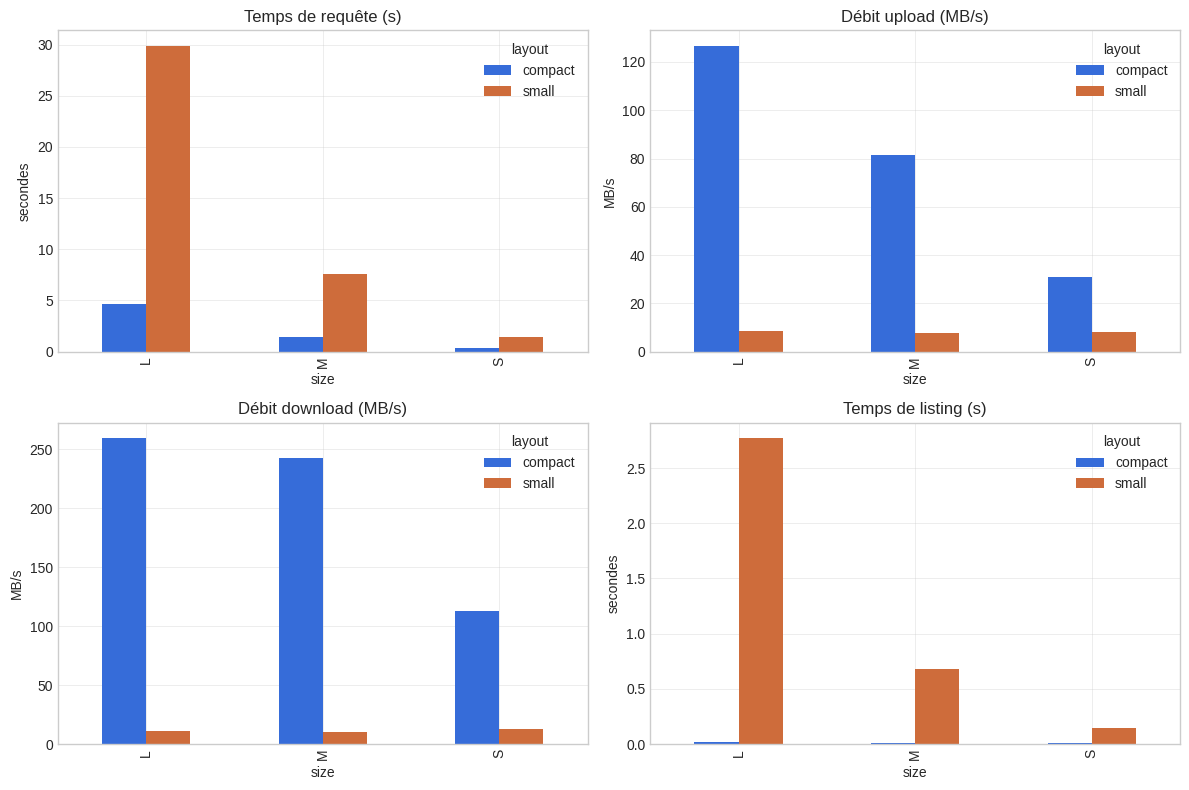

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

query_pivot.plot(kind='bar', ax=axes[0,0], title='Temps de requête (s)')
axes[0,0].set_ylabel('secondes')

upload_pivot.plot(kind='bar', ax=axes[0,1], title='Débit upload (MB/s)')
axes[0,1].set_ylabel('MB/s')

download_pivot.plot(kind='bar', ax=axes[1,0], title='Débit download (MB/s)')
axes[1,0].set_ylabel('MB/s')

listing_pivot.plot(kind='bar', ax=axes[1,1], title='Temps de listing (s)')
axes[1,1].set_ylabel('secondes')

plt.tight_layout()
plt.show()

In [9]:
query_pivot = df.pivot(index="size", columns="layout", values="query_elapsed_s")
upload_pivot = df.pivot(index="size", columns="layout", values="upload_throughput_mb_s")
download_pivot = df.pivot(index="size", columns="layout", values="download_throughput_mb_s")
listing_pivot = df.pivot(index="size", columns="layout", values="listing_elapsed_s")

improvement = pd.DataFrame(index=query_pivot.index)
improvement["query_speedup_x"] = query_pivot["small"] / query_pivot["compact"]
improvement["upload_speedup_x"] = upload_pivot["compact"] / upload_pivot["small"]
improvement["download_speedup_x"] = download_pivot["compact"] / download_pivot["small"]
improvement["listing_speedup_x"] = listing_pivot["small"] / listing_pivot["compact"]

improvement["query_time_reduction_%"] = (1 - query_pivot["compact"] / query_pivot["small"]) * 100
improvement["listing_time_reduction_%"] = (1 - listing_pivot["compact"] / listing_pivot["small"]) * 100
improvement["upload_gain_%"] = (upload_pivot["compact"] / upload_pivot["small"] - 1) * 100
improvement["download_gain_%"] = (download_pivot["compact"] / download_pivot["small"] - 1) * 100

display(improvement.round(2))

,query_speedup_x,upload_speedup_x,download_speedup_x,listing_speedup_x,query_time_reduction_%,listing_time_reduction_%,upload_gain_%,download_gain_%
size,,,,,,,,
L,6.450,15.110,23.710,182.680,84.510,99.450,"1,410.970","2,271.310"
M,5.150,10.680,22.980,54.030,80.570,98.150,968.270,"2,197.780"
S,3.830,3.880,9.120,10.380,73.860,90.370,287.520,811.900


## Interpretation

The results show that compaction improves performance in all tested dimensions.

The effect becomes stronger as the dataset grows:
- listing time drops sharply because the number of objects is much smaller,
- upload and download throughput increase substantially,
- query execution becomes faster, especially for medium and large datasets.

Overall, the results support the hypothesis that many small files create significant overhead in object storage systems, and that compaction is an effective mitigation strategy.